# Component: Thermosteric / Ocean Thermal Expansion

This notebook calibrates, validates, and projects the thermosteric (ocean thermal expansion) component of GMSL rise.

**Primary approach (two-layer ODE + NOAA):** Geoffroy et al. (2013) two-layer
energy balance model fitted to NOAA in situ observations
(0–700 m from 1955, 0–2000 m from 2005) with literature depth corrections,
projected forward using IPCC AR6 GMST trajectories for each SSP.

**Validation**: IPCC AR6 oceandynamics projections are compared
with our model output in histogram and ridge plots (not used in calibration).

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import arete_mpl
arete_mpl.use('poster')

# Local modules
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
sys.path.insert(0, '.')
from slr_data_readers import read_berkeley_earth, read_noaa_thermosteric
from bayesian_models import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior, fit_bayesian_thermosteric,
    solve_twolayer_ode, check_convergence,
)
from slr_projections import project_thermosteric_ensemble
from component_analysis import model_ensemble_draws
from component_projections import (
    read_ipcc_component_nc, ipcc_extract, get_our_stats, get_ipcc_stats,
)
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)

# Paths
H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

# Constants
from slr_forecast.config import BASELINE_YEAR, Z_90
N_SAMPLES = 2000
M_TO_MM = 1000.0

/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## 1. Data Loading

**Primary observations**: NOAA thermosteric SL (0–700 m, 1955–2025; 0–2000 m, 2005–2025) — direct in situ measurements used for two-layer model calibration.

**Loaded but unused in calibration**: EN4 global subsurface T (0–700 m, 1970–2021) — retained for potential downstream use (e.g., Greenland discharge coupling).

**Loaded but unused in calibration**: Frederikse et al. (2020) steric component — pre-1955 is model-constrained, not pure observations; retained for reference.

In [ ]:
# ── Berkeley Earth monthly temperature ──
df_temp = pd.read_hdf(H5_PATH, key='harmonized/df_berkeley_h')
temp_monthly = df_temp['temperature'].values
# Convert datetime index to decimal year
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values

# Annual temperature (used as forcing for two-layer ODE fit and projections)
yr_int = np.floor(temp_time_monthly).astype(int)
unique_yrs = np.unique(yr_int)
T_annual = np.array([temp_monthly[yr_int == y].mean() for y in unique_yrs])
T_annual_years = unique_yrs + 0.5

# ── NOAA thermosteric SL (0–700 m, yearly, 1955–2025) — PRIMARY ──
NOAA_TSL_H5_KEY = 'harmonized/df_noaa_tsl_0_700m'
try:
    df_noaa_tsl = pd.read_hdf(H5_PATH, NOAA_TSL_H5_KEY)
except KeyError:
    from slr_forecast.readers.forcing import read_noaa_thermosteric_yearly
    df_noaa_tsl = read_noaa_thermosteric_yearly(
        f'{RAW_DIR}/steric/noaa_tsl_yearly_0-700m.dat')
    df_noaa_tsl.to_hdf(H5_PATH, NOAA_TSL_H5_KEY, mode='a')

noaa_year = df_noaa_tsl['decimal_year'].values
noaa_tsl_mm = df_noaa_tsl['tsl_mm'].values
noaa_tsl_se_mm = df_noaa_tsl['tsl_se_mm'].values

# Rebaseline to 1995–2006 mean and convert mm → m
bl_mask = (noaa_year >= 1995.0) & (noaa_year <= 2006.0)
noaa_tsl_m = (noaa_tsl_mm - noaa_tsl_mm[bl_mask].mean()) / M_TO_MM
noaa_tsl_se_m = noaa_tsl_se_mm / M_TO_MM

print(f'NOAA thermosteric SL (0–700 m): {noaa_year[0]:.0f}–{noaa_year[-1]:.0f} '
      f'({len(noaa_year)} pts)')
print(f'  Range: [{noaa_tsl_m.min()*M_TO_MM:.1f}, {noaa_tsl_m.max()*M_TO_MM:.1f}] mm '
      f'(rebased to 1995–2006)')

# ── NOAA thermosteric SL (0–2000 m, yearly, 2005–2025) — CALIBRATION ──
# Same instrument lineage as 0–700 m; constrains deep-ocean response (b_d)
# in the two-layer model fit.
NOAA_DEEP_H5_KEY = 'harmonized/df_noaa_tsl_0_2000m'
try:
    df_noaa_deep = pd.read_hdf(H5_PATH, NOAA_DEEP_H5_KEY)
except KeyError:
    from slr_forecast.readers.forcing import read_noaa_thermosteric_yearly
    df_noaa_deep = read_noaa_thermosteric_yearly(
        f'{RAW_DIR}/steric/noaa_tsl_yearly_0-2000m.dat')
    df_noaa_deep.to_hdf(H5_PATH, NOAA_DEEP_H5_KEY, mode='a')

noaa_deep_year = df_noaa_deep['decimal_year'].values
noaa_deep_mm = df_noaa_deep['tsl_mm'].values
noaa_deep_se_mm = df_noaa_deep['tsl_se_mm'].values

# Rebaseline to 1995–2005 mean of the 0–700 m record cannot be computed
# (0–2000 m starts at 2005), so rebaseline at the first point (2005.5).
noaa_deep_m = (noaa_deep_mm - noaa_deep_mm[0]) / M_TO_MM
noaa_deep_se_m = noaa_deep_se_mm / M_TO_MM

print(f'NOAA thermosteric SL (0–2000 m): {noaa_deep_year[0]:.0f}–{noaa_deep_year[-1]:.0f} '
      f'({len(noaa_deep_year)} pts, calibration)')

# ── EN4 global subsurface T (0–700 m, monthly, 1970–2021) — LOADED, NOT USED IN FIT ──
EN4_GLOBAL_H5_KEY = 'harmonized/df_en4_global_0_700m'
try:
    df_en4_global = pd.read_hdf(H5_PATH, EN4_GLOBAL_H5_KEY)
except KeyError:
    from slr_forecast.readers.ocean_temp import read_en4_regional
    df_en4_global = read_en4_regional(
        f'{RAW_DIR}/ocean_temp/en4/',
        lat_bounds=(-90.0, 90.0),
        lon_bounds=(-180.0, 180.0),
        depth_bounds=(0.0, 700.0),
    )
    df_en4_global.to_hdf(H5_PATH, EN4_GLOBAL_H5_KEY, mode='a')

en4_global_time = df_en4_global['decimal_year'].values
en4_global_temp = df_en4_global['temperature'].values  # anomaly, °C
en4_global_sigma = df_en4_global['temperature_sigma'].values

print(f'EN4 global subsurface T (0–700 m): {en4_global_time[0]:.1f}–'
      f'{en4_global_time[-1]:.1f} ({len(en4_global_temp)} months)')

# ── Frederikse thermosteric (loaded for reference, not used in fit) ──
# Full-depth steric, pre-1955 is model-constrained.
df_fred = pd.read_hdf(H5_PATH, key='derived/df_frederikse_thermo')
fred_year = df_fred['year'].values + 0.5  # mid-year decimal
fred_steric = df_fred['steric'].values
fred_steric_sigma = df_fred['steric_sigma'].values

bl_idx_fred = np.argmin(np.abs(fred_year - BASELINE_YEAR))
steric_rebase = fred_steric - fred_steric[bl_idx_fred]

print(f'Frederikse steric (reference): {fred_year[0]:.0f}–{fred_year[-1]:.0f}, '
      f'{len(fred_year)} points')

## 2. Two-layer physical ODE (NOAA 0--700 m + 0--2000 m)

Fit the Geoffroy et al. (2013) two-layer energy balance model simultaneously
to NOAA thermosteric SL at two depth ranges:

- **0--700 m** (1955--2025): constrains upper-ocean response ($a$, $b_u$, $\tau_u$)
- **0--2000 m** (2005--2025): additionally constrains deep-ocean sensitivity ($b_d$); $\tau_d$ is fixed at 150 yr

Below-2000 m contribution is added as a literature rate correction (0.07 mm/yr).

**Model:**
$$\frac{dS_u}{dt} = \frac{T(t) - S_u}{\tau_u}, \quad
  \frac{dS_d}{dt} = \frac{S_u - S_d}{\tau_d}$$

$$H_{\rm upper}(t) = a\,S_u^2 + b_u\,S_u + c\,(t - t_0)$$
$$H_{\rm total}(t) = H_{\rm upper}(t) + b_d\,S_d$$

tau_d fixed at 150 yr (Geoffroy et al. 2013)
OLS init: a=19.099 mm/C^2, b_u=46.792 mm/C, b_d=0.001 mm/C
  c=0.0150 mm/yr, tau_u=8 yr
  log_prob(init) = 457.3

Running emcee: 48 walkers, 4000 burn-in + 12000 production (6 params)...


  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 3/4000 [00:00<02:25, 27.55it/s]

  0%|          | 6/4000 [00:00<02:21, 28.16it/s]

  0%|          | 9/4000 [00:00<02:19, 28.54it/s]

...

100%|█████████▉| 11994/12000 [07:24<00:00, 27.38it/s]

100%|█████████▉| 11997/12000 [07:24<00:00, 27.39it/s]

100%|██████████| 12000/12000 [07:24<00:00, 27.35it/s]

100%|██████████| 12000/12000 [07:24<00:00, 27.00it/s]

Samples: 576000
Acceptance fraction: 0.454

TWO-LAYER THERMOSTERIC MODEL (tau_d = 150 yr fixed)
  a              : 19.2503 mm/C^2  [9.5207, 29.4244]
  b_u            : 50.1941 mm/C  [40.2090, 72.2750]
  b_d            : 67.7685 mm/C  [36.8423, 101.6344]
  c              : 0.0204 mm/yr  [-0.1099, 0.1353]
  tau_u          : 11.0896 yr  [5.9403, 23.6539]
  sigma_extra    : 1.9653 mm  [1.6898, 2.2959]

  R^2 (0-700m):  0.9651
  R^2 (0-2000m): 0.9783

Rate comparison (model vs NOAA):
  1993-2025:
    Upper:  model 0.956, NOAA 1.013 mm/yr
    Total:  model 1.275, NOAA 1.453 mm/yr
    Full-depth (+ below 2000m): 1.345 mm/yr
  2005-2025:
    Upper:  model 1.103, NOAA 1.070 mm/yr
    Total:  model 1.461, NOAA 1.453 mm/yr
    Full-depth (+ below 2000m): 1.531 mm/yr


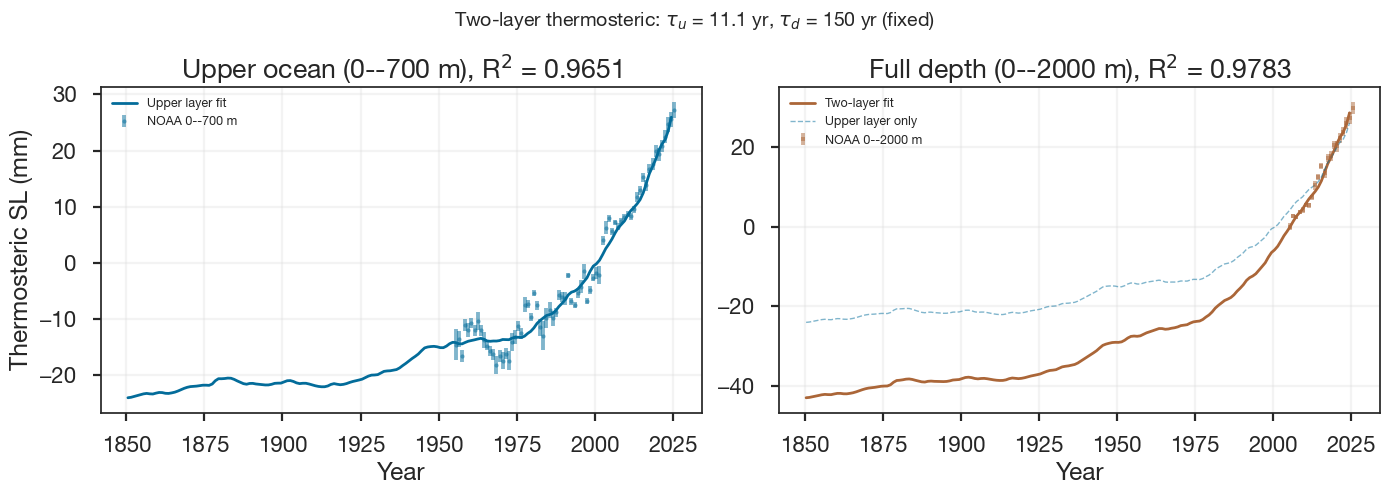

In [3]:
# ── Two-layer fit to NOAA 0-700m + 0-2000m ──
# tau_d fixed at 150 yr (Geoffroy et al. 2013); data demeaned to remove offsets.
# Free parameters: a, b_u, b_d, c, log_tau_u, log_sigma_extra (6 total).
import emcee

TAU_D_FIXED = 150.0  # yr, Geoffroy et al. (2013) CMIP5 range: 100-300 yr

# ── Li et al. (2022) bias correction: 14% low bias in NOAA ──
# NOAA thermosteric SL underestimates due to sparse sampling of the
# Southern Ocean and deep tropics. Apply correction to data before fitting.
STRUCTURAL_FRAC = 0.14
noaa_700_corrected = noaa_tsl_m * (1.0 + STRUCTURAL_FRAC)
noaa_2000_corrected = noaa_deep_m * (1.0 + STRUCTURAL_FRAC)

# Residual structural uncertainty after correction (~5% of signal)
RESIDUAL_STRUCTURAL = 0.05
sigma_700_total = np.sqrt(
    noaa_tsl_se_m**2 + (RESIDUAL_STRUCTURAL * np.abs(noaa_700_corrected))**2
)
sigma_2000_total = np.sqrt(
    noaa_deep_se_m**2 + (RESIDUAL_STRUCTURAL * np.abs(noaa_2000_corrected))**2
)

# ── Demean both datasets ──
noaa_700_dm = noaa_700_corrected - noaa_700_corrected.mean()
noaa_2000_dm = noaa_2000_corrected - noaa_2000_corrected.mean()

# ── Map observation times to annual grid indices ──
obs_idx_700 = np.array([
    np.argmin(np.abs(T_annual_years - y)) for y in noaa_year
])
obs_idx_2000 = np.array([
    np.argmin(np.abs(T_annual_years - y)) for y in noaa_deep_year
])

# Elapsed time (demeaned to match data)
I0_700 = noaa_year - T_annual_years[0]
I0_700_dm = I0_700 - I0_700.mean()
I0_2000 = noaa_deep_year - T_annual_years[0]
I0_2000_dm = I0_2000 - I0_2000.mean()

# Below-2000 m correction
RATE_BELOW_2000 = 0.07e-3  # m/yr

# ── Pre-compute annual T grid ──
dt_ann = np.diff(T_annual_years)
T_avg_ann = 0.5 * (T_annual[:-1] + T_annual[1:])
n_ann = len(T_annual)

def twolayer_log_prob(theta):
    a, b_u, b_d, c, log_tau_u, log_sigma_extra = theta

    if a < 0 or b_u < 0 or b_d < 0:
        return -np.inf

    tau_u = np.exp(log_tau_u)
    sigma_extra = np.exp(log_sigma_extra)

    if tau_u < 0.1 or tau_u > 500:
        return -np.inf

    # ── Solve two-layer ODE ──
    Su = np.empty(n_ann)
    Su[0] = T_annual[0]
    inv_tau_u = 1.0 / tau_u
    for i in range(n_ann - 1):
        decay = np.exp(-dt_ann[i] * inv_tau_u)
        Su[i + 1] = T_avg_ann[i] + (Su[i] - T_avg_ann[i]) * decay

    Sd = np.empty(n_ann)
    Sd[0] = T_annual[0]
    inv_tau_d = 1.0 / TAU_D_FIXED
    for i in range(n_ann - 1):
        su_avg = 0.5 * (Su[i] + Su[i + 1])
        decay = np.exp(-dt_ann[i] * inv_tau_d)
        Sd[i + 1] = su_avg + (Sd[i] - su_avg) * decay

    # ── Likelihood 1: NOAA 0-700m (demeaned) ──
    Su_obs = Su[obs_idx_700]
    H_upper = a * Su_obs**2 + b_u * Su_obs + c * I0_700
    H_upper_dm = H_upper - H_upper.mean()
    sig_700 = np.sqrt(sigma_700_total**2 + sigma_extra**2)
    resid_700 = noaa_700_dm - H_upper_dm
    ll_700 = -0.5 * np.sum((resid_700 / sig_700)**2 + np.log(sig_700**2))

    # ── Likelihood 2: NOAA 0-2000m (demeaned) ──
    Su_obs_d = Su[obs_idx_2000]
    Sd_obs = Sd[obs_idx_2000]
    H_total = a * Su_obs_d**2 + b_u * Su_obs_d + b_d * Sd_obs + c * I0_2000
    H_total_dm = H_total - H_total.mean()
    sig_2000 = np.sqrt(sigma_2000_total**2 + sigma_extra**2)
    resid_2000 = noaa_2000_dm - H_total_dm
    ll_2000 = -0.5 * np.sum((resid_2000 / sig_2000)**2 + np.log(sig_2000**2))

    # ── Priors ──
    lp = 0.0
    lp += -a / 0.022                                    # Exponential(mean=0.022 m/C^2)
    lp += -0.5 * (b_u / 0.15)**2                       # HalfNormal(sigma=0.15 m/C)
    lp += -0.5 * (b_d / 0.10)**2                       # HalfNormal(sigma=0.10 m/C)
    lp += -0.5 * ((c - 0.0003) / 0.0005)**2            # Normal(0.3 mm/yr, 0.5 mm/yr)
    lp += -0.5 * ((log_tau_u - np.log(8)) / 0.5)**2    # LogNormal(log(8), 0.5)
    lp += -np.log(1 + (sigma_extra / 0.003)**2) + log_sigma_extra  # HalfCauchy(0.003)

    return ll_700 + ll_2000 + lp

# ── OLS initialization ──
tau_u_init = 8.0
Su_init, Sd_init = solve_twolayer_ode(
    T_annual, T_annual_years, tau_u_init, TAU_D_FIXED
)

# Upper layer OLS on demeaned data
Su_obs_init = Su_init[obs_idx_700]
X_700 = np.column_stack([Su_obs_init**2, Su_obs_init, I0_700])
X_700_dm = X_700 - X_700.mean(axis=0)
beta_700 = np.linalg.lstsq(X_700_dm, noaa_700_dm, rcond=None)[0]

# Deep layer OLS
Sd_obs_init = Sd_init[obs_idx_2000]
Su_obs_d_init = Su_init[obs_idx_2000]
X_2000 = np.column_stack([Su_obs_d_init**2, Su_obs_d_init, Sd_obs_init, I0_2000])
X_2000_dm = X_2000 - X_2000.mean(axis=0)
beta_2000 = np.linalg.lstsq(X_2000_dm, noaa_2000_dm, rcond=None)[0]

theta0 = np.array([
    max(beta_700[0], 1e-6),      # a
    max(beta_700[1], 1e-6),      # b_u
    max(beta_2000[2], 1e-6),     # b_d
    beta_700[2],                  # c
    np.log(tau_u_init),           # log_tau_u
    np.log(0.001),                # log_sigma_extra
])

print(f'tau_d fixed at {TAU_D_FIXED:.0f} yr (Geoffroy et al. 2013)')
print(f'OLS init: a={theta0[0]*1e3:.3f} mm/C^2, b_u={theta0[1]*1e3:.3f} mm/C, '
      f'b_d={theta0[2]*1e3:.3f} mm/C')
print(f'  c={theta0[3]*1e3:.4f} mm/yr, tau_u={tau_u_init:.0f} yr')
print(f'  log_prob(init) = {twolayer_log_prob(theta0):.1f}')

# ── MCMC ──
ndim = 6
n_walkers = 48
n_burnin = 4000
n_production = 12000

rng = np.random.default_rng(42)
pos0 = theta0 + 1e-4 * rng.standard_normal((n_walkers, ndim))
pos0[:, :3] = np.abs(pos0[:, :3])  # ensure positivity

print(f'\nRunning emcee: {n_walkers} walkers, {n_burnin} burn-in + '
      f'{n_production} production ({ndim} params)...')
sampler = emcee.EnsembleSampler(n_walkers, ndim, twolayer_log_prob)
state = sampler.run_mcmc(pos0, n_burnin, progress=True)
sampler.reset()
sampler.run_mcmc(state, n_production, progress=True)

flat = sampler.get_chain(flat=True)
print(f'Samples: {flat.shape[0]}')
print(f'Acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}')

# ── Extract posteriors ──
a_post = flat[:, 0]
bu_post = flat[:, 1]
bd_post = flat[:, 2]
c_post = flat[:, 3]
tau_u_post = np.exp(flat[:, 4])
sigma_extra_post = np.exp(flat[:, 5])

param_names = ['a', 'b_u', 'b_d', 'c', 'tau_u', 'sigma_extra']
param_vals = [a_post * M_TO_MM, bu_post * M_TO_MM, bd_post * M_TO_MM,
              c_post * M_TO_MM, tau_u_post, sigma_extra_post * M_TO_MM]
param_units = ['mm/C^2', 'mm/C', 'mm/C', 'mm/yr', 'yr', 'mm']

print(f'\n{"="*70}')
print(f'TWO-LAYER THERMOSTERIC MODEL (tau_d = {TAU_D_FIXED:.0f} yr fixed)')
print(f'{"="*70}')
for name, vals, unit in zip(param_names, param_vals, param_units):
    med = np.median(vals)
    lo, hi = np.percentile(vals, [5, 95])
    print(f'  {name:15s}: {med:.4f} {unit}  [{lo:.4f}, {hi:.4f}]')

# ── Posterior-median model prediction (NOT demeaned — for plotting) ──
tau_u_med = np.median(tau_u_post)
Su_fit, Sd_fit = solve_twolayer_ode(T_annual, T_annual_years, tau_u_med, TAU_D_FIXED)

a_med = np.median(a_post)
bu_med = np.median(bu_post)
bd_med = np.median(bd_post)
c_med = np.median(c_post)

I0_all = T_annual_years - T_annual_years[0]
H_upper_fit = a_med * Su_fit**2 + bu_med * Su_fit + c_med * I0_all
H_total_fit = H_upper_fit + bd_med * Sd_fit

# Rebase to match NOAA baselines for plotting
bl_mask = (T_annual_years >= 1995) & (T_annual_years <= 2006)
H_upper_fit -= H_upper_fit[bl_mask].mean()
# For 0-2000m, rebase to first 0-2000m data point
idx_2005 = np.argmin(np.abs(T_annual_years - noaa_deep_year[0]))
H_total_fit -= H_total_fit[idx_2005]

# R^2 (on original, not demeaned, data)
H_upper_at_700 = H_upper_fit[obs_idx_700]
r2_700 = 1 - np.sum((noaa_700_corrected - H_upper_at_700)**2) / np.sum((noaa_700_corrected - noaa_700_corrected.mean())**2)
H_total_at_2000 = H_total_fit[obs_idx_2000]
r2_2000 = 1 - np.sum((noaa_2000_corrected - H_total_at_2000)**2) / np.sum((noaa_2000_corrected - noaa_2000_corrected.mean())**2)

print(f'\n  R^2 (0-700m):  {r2_700:.4f}')
print(f'  R^2 (0-2000m): {r2_2000:.4f}')

# ── Rate comparison by period ──
print(f'\nRate comparison (model vs NOAA):')
for label, lo, hi in [('1993-2025', 1993, 2025), ('2005-2025', 2005, 2025)]:
    mask = (T_annual_years >= lo) & (T_annual_years <= hi)
    p_u = np.polyfit(T_annual_years[mask] - lo, H_upper_fit[mask] * M_TO_MM, 1)
    p_t = np.polyfit(T_annual_years[mask] - lo, H_total_fit[mask] * M_TO_MM, 1)
    m700 = (noaa_year >= lo) & (noaa_year <= hi)
    m2000 = (noaa_deep_year >= lo) & (noaa_deep_year <= hi)
    r700 = np.polyfit(noaa_year[m700] - lo, noaa_700_corrected[m700] * M_TO_MM, 1)[0]
    r2000 = np.polyfit(noaa_deep_year[m2000] - lo, noaa_2000_corrected[m2000] * M_TO_MM, 1)[0] if m2000.sum() > 2 else float('nan')
    print(f'  {label}:')
    print(f'    Upper:  model {p_u[0]:.3f}, NOAA {r700:.3f} mm/yr')
    print(f'    Total:  model {p_t[0]:.3f}, NOAA {r2000:.3f} mm/yr')
    print(f'    Full-depth (+ below 2000m): {p_t[0] + RATE_BELOW_2000 * M_TO_MM:.3f} mm/yr')

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.errorbar(noaa_year, noaa_700_corrected * M_TO_MM, yerr=sigma_700_total * M_TO_MM,
            fmt='o', ms=3, color='C0', alpha=0.5, label='NOAA 0--700 m')
ax.plot(T_annual_years, H_upper_fit * M_TO_MM, 'C0-', lw=2, label='Upper layer fit')
ax.set_xlabel('Year')
ax.set_ylabel('Thermosteric SL (mm)')
ax.set_title(f'Upper ocean (0--700 m), R$^2$ = {r2_700:.4f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.errorbar(noaa_deep_year, noaa_2000_corrected * M_TO_MM, yerr=sigma_2000_total * M_TO_MM,
            fmt='s', ms=3, color='C1', alpha=0.5, label='NOAA 0--2000 m')
ax.plot(T_annual_years, H_total_fit * M_TO_MM, 'C1-', lw=2, label='Two-layer fit')
ax.plot(T_annual_years, H_upper_fit * M_TO_MM, 'C0--', lw=1, alpha=0.5,
        label='Upper layer only')
ax.set_xlabel('Year')
ax.set_title(f'Full depth (0--2000 m), R$^2$ = {r2_2000:.4f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Two-layer thermosteric: $\\tau_u$ = {tau_u_med:.1f} yr, '
             f'$\\tau_d$ = {TAU_D_FIXED:.0f} yr (fixed)', fontsize=14)
plt.tight_layout()
plt.show()



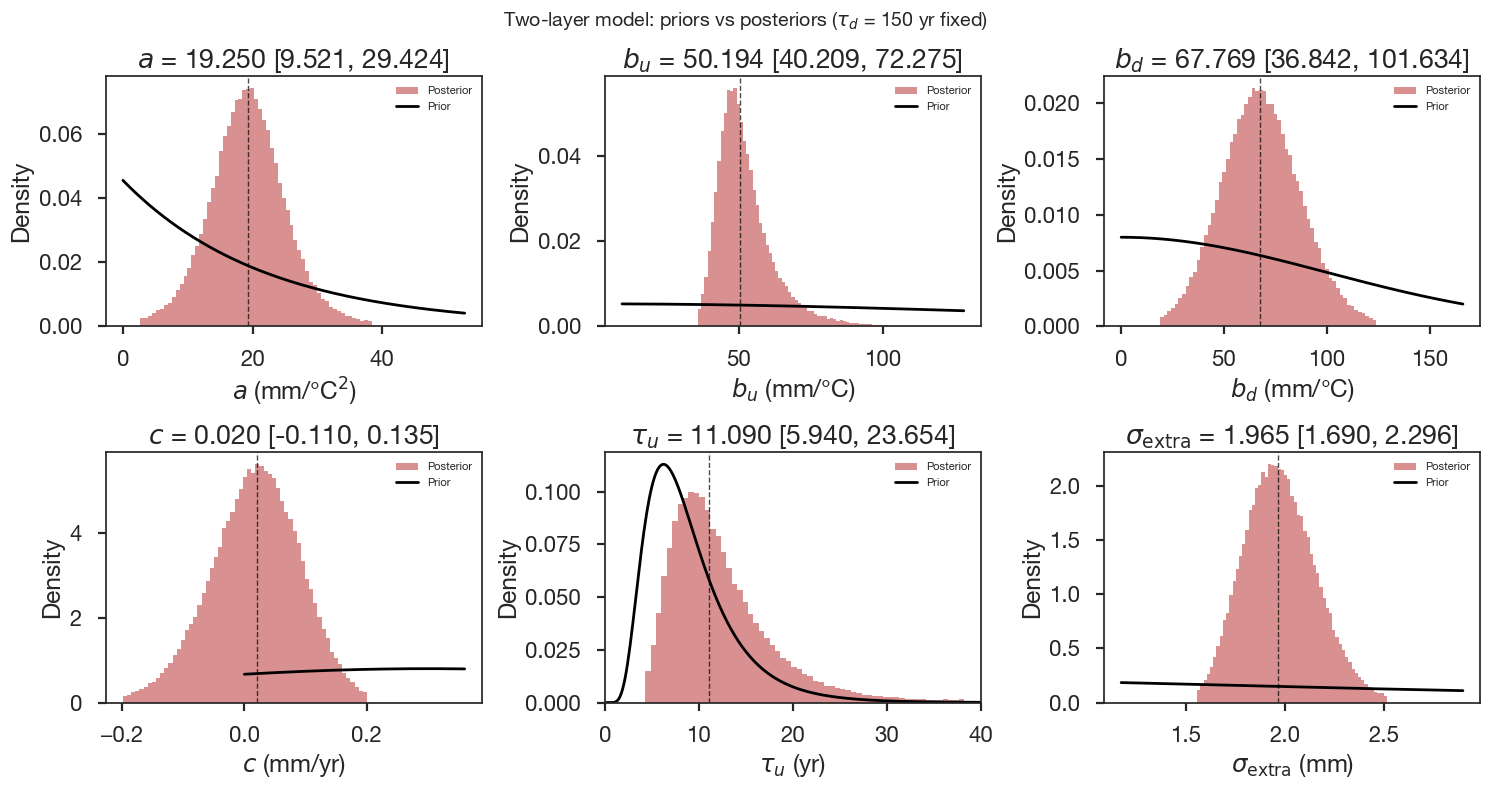

In [4]:
# ── Prior vs posterior: two-layer thermosteric model ──
from scipy.stats import expon, halfnorm, norm, halfcauchy, lognorm

fig_pp, axes_pp = plt.subplots(2, 3, figsize=(15, 8))
axes_pp = axes_pp.ravel()

# Each entry: (label, unit, posterior samples in display units,
#              scipy prior distribution in display units, optional xlim)
_pp_defs = [
    ('$a$', 'mm/°C$^2$', a_post * M_TO_MM,
     expon(scale=0.022 * M_TO_MM), None),
    ('$b_u$', 'mm/°C', bu_post * M_TO_MM,
     halfnorm(scale=0.15 * M_TO_MM), None),
    ('$b_d$', 'mm/°C', bd_post * M_TO_MM,
     halfnorm(scale=0.10 * M_TO_MM), None),
    ('$c$', 'mm/yr', c_post * M_TO_MM,
     norm(loc=0.0003 * M_TO_MM, scale=0.0005 * M_TO_MM), None),
    (r'$\tau_u$', 'yr', tau_u_post,
     lognorm(s=0.5, scale=8.0), (0, 40)),
    (r'$\sigma_{\mathrm{extra}}$', 'mm', sigma_extra_post * M_TO_MM,
     halfcauchy(scale=0.003 * M_TO_MM), None),
]

for ax, (label, unit, post, prior_dist, xlim) in zip(axes_pp, _pp_defs):
    lo_p, hi_p = np.percentile(post, [0.5, 99.5])
    bins = np.linspace(lo_p, hi_p, 60)
    ax.hist(post, bins=bins, density=True, alpha=0.5,
            color=COMP_COLORS['Thermosteric'], label='Posterior')

    # Prior curve over a range that covers both prior mass and posterior
    if xlim is not None:
        x_pr = np.linspace(max(xlim[0], 1e-6), xlim[1], 300)
    else:
        margin = 0.4 * (hi_p - lo_p)
        x_pr = np.linspace(max(lo_p - margin, 1e-8), hi_p + margin, 300)
    ax.plot(x_pr, prior_dist.pdf(x_pr), 'k-', lw=2, label='Prior')

    # Posterior median + 90% CI annotation
    med = np.median(post)
    ci5, ci95 = np.percentile(post, [5, 95])
    ax.axvline(med, color='k', ls='--', lw=1, alpha=0.7)

    ax.set_xlabel(f'{label} ({unit})')
    ax.set_ylabel('Density')
    ax.set_title(f'{label} = {med:.3f} [{ci5:.3f}, {ci95:.3f}]')
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.legend(fontsize=8)

fig_pp.suptitle(
    f'Two-layer model: priors vs posteriors '
    f'($\\tau_d$ = {TAU_D_FIXED:.0f} yr fixed)',
    fontsize=14,
)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_ocean_priors_posteriors.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3. Projections under SSP temperatures

Project the fitted two-layer model forward using IPCC AR6 GMST
trajectories for each SSP. MC samples are drawn from the posterior
to propagate parameter uncertainty. The below-2000 m contribution
is added as a literature rate correction.

The model is evaluated over the full 1950--2150 trajectory
(hindcast + projection) for each MC sample.


In [5]:
# ── Project two-layer model: full trajectory 1950-2150 ──
from component_io import save_ocean_hybrid, PROJ_YEARS, PROJ_SSPS, N_SAMPLES

SSP_H5_MAP = {
    'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
    'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
}

RATE_BELOW_2000 = 0.07e-3  # m/yr (Purkey & Johnson 2010)
SIGMA_BELOW_2000 = 0.04e-3  # m/yr
N_MC = N_SAMPLES  # 2000

# ── SSP temperature baseline offset ──
# IPCC SSP temps are relative to pre-industrial; Berkeley Earth is
# relative to 1951-1980. Compute offset from overlap period.
df_ssp_ref = pd.read_hdf(H5_PATH, f'projections/temp/{SSP_H5_MAP["SSP2-4.5"]}')
ssp_ref_years = df_ssp_ref['decimal_year'].values + 0.5
ssp_ref_T = df_ssp_ref['temperature'].values

overlap = (T_annual_years >= 2015.5) & (T_annual_years <= 2024.5)
ssp_overlap = (ssp_ref_years >= 2015.5) & (ssp_ref_years <= 2024.5)
T_OFFSET = ssp_ref_T[ssp_overlap].mean() - T_annual[overlap].mean()
print(f'SSP-to-Berkeley baseline offset: {T_OFFSET:.3f} C')

# ── Thin posterior for MC sampling ──
rng_proj = np.random.default_rng(42)
idx_thin = rng_proj.choice(len(flat), size=N_MC, replace=False)
mc_a = flat[idx_thin, 0]
mc_bu = flat[idx_thin, 1]
mc_bd = flat[idx_thin, 2]
mc_c = flat[idx_thin, 3]
mc_tau_u = np.exp(flat[idx_thin, 4])
mc_sigma_extra = np.exp(flat[idx_thin, 5])

# ── Construct full-depth observational estimate ──
# The model projects full-depth thermosteric (upper + deep + below-2000m).
# Observations must match:
#   1956-2005: 0-700m corrected only (no deeper data available)
#   2006-2026: 0-700m + (700-2000m increment) + below-2000m rate
# The 700-2000m increment is the change in 0-2000m minus the change in 0-700m,
# both measured from the first 0-2000m data point (2006). This is continuous
# at the splice because the increment is zero at 2006.
obs_years = noaa_year.copy()
obs_H = noaa_700_corrected.copy()

# Add below-2000m rate correction for all years
obs_H += RATE_BELOW_2000 * (obs_years - BASELINE_YEAR)

# Add 700-2000m increment where 0-2000m data is available (2006+)
# 700-2000m change from 2006 = (0-2000m change from 2006) - (0-700m change from 2006)
noaa_700_at_deep_years = np.interp(noaa_deep_year, noaa_year, noaa_700_corrected)
deep_layer_increment = noaa_2000_corrected - (noaa_700_at_deep_years - noaa_700_at_deep_years[0])

for i, y in enumerate(obs_years):
    if y >= noaa_deep_year[0]:
        obs_H[i] += np.interp(y, noaa_deep_year, deep_layer_increment)

# Uncertainty: combine 0-700m and deep-layer terms
obs_sigma = sigma_700_total.copy()
sigma_below_2000 = SIGMA_BELOW_2000 * np.abs(obs_years - BASELINE_YEAR)
obs_sigma = np.sqrt(obs_sigma**2 + sigma_below_2000**2)
# Add 0-2000m measurement uncertainty for years with deep data
for i, y in enumerate(obs_years):
    if y >= noaa_deep_year[0]:
        sig_deep = np.interp(y, noaa_deep_year, sigma_2000_total)
        obs_sigma[i] = np.sqrt(obs_sigma[i]**2 + sig_deep**2)

print(f'Full-depth obs: {int(obs_years[0])}-{int(obs_years[-1])} ({len(obs_years)} pts)')
print(f'  0-700m only period: {int(obs_years[0])}-{int(noaa_deep_year[0]-1)}')
print(f'  Full-depth period: {int(noaa_deep_year[0])}-{int(obs_years[-1])}')
print(f'  At 2020: {np.interp(2020, obs_years, obs_H)*M_TO_MM:.1f} mm')

# ── Project each SSP ──
proj_dict = {}
for ssp in PROJ_SSPS:
    # Load SSP temperature, convert to Berkeley Earth baseline
    df_ssp = pd.read_hdf(H5_PATH, f'projections/temp/{SSP_H5_MAP[ssp]}')
    ssp_years = df_ssp['decimal_year'].values + 0.5
    ssp_T = df_ssp['temperature'].values - T_OFFSET
    ssp_T_sigma = df_ssp['temperature_sigma'].values

    # Splice historical + SSP future
    future_mask = ssp_years > T_annual_years[-1]
    T_proj = np.concatenate([T_annual, ssp_T[future_mask]])
    years_proj = np.concatenate([T_annual_years, ssp_years[future_mask]])

    # MC samples from posterior
    full_samples = np.zeros((N_MC, len(PROJ_YEARS)))
    upper_samples = np.zeros((N_MC, len(PROJ_YEARS)))
    twolayer_samples = np.zeros((N_MC, len(PROJ_YEARS)))

    for k in range(N_MC):
        # Add temperature noise to SSP portion
        T_k = T_proj.copy()
        n_hist = len(T_annual)
        T_k[n_hist:] += rng_proj.normal(0, ssp_T_sigma[future_mask])

        # Solve ODE with this sample's parameters
        Su_k, Sd_k = solve_twolayer_ode(T_k, years_proj, mc_tau_u[k], TAU_D_FIXED)

        # Model prediction (full trajectory)
        I0_k = years_proj - years_proj[0]
        H_upper_k = mc_a[k] * Su_k**2 + mc_bu[k] * Su_k + mc_c[k] * I0_k
        H_total_k = H_upper_k + mc_bd[k] * Sd_k

        # Add below-2000m correction with uncertainty
        rate_deep_k = RATE_BELOW_2000 + rng_proj.normal(0, SIGMA_BELOW_2000)
        H_deep_k = rate_deep_k * (years_proj - BASELINE_YEAR)
        H_full_k = H_total_k + H_deep_k

        # Rebase to BASELINE_YEAR (2000)
        ib = np.argmin(np.abs(years_proj - BASELINE_YEAR))
        H_full_k -= H_full_k[ib]
        H_upper_k -= H_upper_k[ib]
        H_total_k -= H_total_k[ib]

        # Interpolate to PROJ_YEARS
        full_samples[k, :] = np.interp(PROJ_YEARS, years_proj, H_full_k)
        upper_samples[k, :] = np.interp(PROJ_YEARS, years_proj, H_upper_k)
        twolayer_samples[k, :] = np.interp(PROJ_YEARS, years_proj, H_total_k)

    proj_dict[ssp] = {
        'samples': full_samples,
        'median': np.median(full_samples, axis=0),
        'p5': np.percentile(full_samples, 5, axis=0),
        'p17': np.percentile(full_samples, 17, axis=0),
        'p83': np.percentile(full_samples, 83, axis=0),
        'p95': np.percentile(full_samples, 95, axis=0),
        'upper_samples': upper_samples,
        'twolayer_samples': twolayer_samples,
    }

    med_2050 = proj_dict[ssp]['median'][PROJ_YEARS == 2050][0] * M_TO_MM
    med_2100 = proj_dict[ssp]['median'][PROJ_YEARS == 2100][0] * M_TO_MM
    med_2005 = proj_dict[ssp]['median'][PROJ_YEARS == 2005][0] * M_TO_MM
    print(f'{ssp}: baseline={med_2005:.1f} mm, 2050={med_2050:.0f} mm, 2100={med_2100:.0f} mm')

# ── Save ──
save_ocean_hybrid(
    obs_years=obs_years,
    obs_H=obs_H,
    obs_sigma=obs_sigma,
    proj_dict=proj_dict,
    extra_metadata={
        'model_type': 'twolayer_noaa',
        'hindcast_source': 'Two-layer Geoffroy ODE evaluated at Berkeley Earth GMST',
        'projection_source': 'Two-layer Geoffroy ODE + IPCC AR6 GMST trajectories',
        'obs_description': 'Full-depth estimate: 0-700m (Li 14% corrected) + 700-2000m increment (2006+) + below-2000m rate',
        'obs_bias_correction': 'Li et al. (2022) 14% structural correction applied',
        'tau_u_median_yr': float(np.median(tau_u_post)),
        'tau_d_fixed_yr': TAU_D_FIXED,
        'a_median_mm_C2': float(np.median(a_post) * M_TO_MM),
        'bu_median_mm_C': float(np.median(bu_post) * M_TO_MM),
        'bd_median_mm_C': float(np.median(bd_post) * M_TO_MM),
        'c_median_mm_yr': float(np.median(c_post) * M_TO_MM),
        'rate_below_2000_mm_yr': RATE_BELOW_2000 * 1e3,
    },
)
print(f'\nSaved to component_results.h5')

# ── Save fit diagnostic data for results_figures ──
# Must be AFTER save_ocean_hybrid, which deletes/recreates the ocean group.
import h5py as _h5_fit
from component_io import DEFAULT_H5_PATH as _COMP_H5
with _h5_fit.File(_COMP_H5, 'a') as _hf:
    if 'ocean/fit_diagnostic' in _hf:
        del _hf['ocean/fit_diagnostic']
    _fg = _hf.create_group('ocean/fit_diagnostic')
    _fg.create_dataset('noaa_year', data=noaa_year)
    _fg.create_dataset('noaa_700_corrected_mm', data=noaa_700_corrected * M_TO_MM)
    _fg.create_dataset('sigma_700_total_mm', data=sigma_700_total * M_TO_MM)
    _fg.create_dataset('noaa_deep_year', data=noaa_deep_year)
    _fg.create_dataset('noaa_2000_corrected_mm', data=noaa_2000_corrected * M_TO_MM)
    _fg.create_dataset('sigma_2000_total_mm', data=sigma_2000_total * M_TO_MM)
    _fg.create_dataset('T_annual_years', data=T_annual_years)
    _fg.create_dataset('H_upper_fit_mm', data=H_upper_fit * M_TO_MM)
    _fg.create_dataset('H_total_fit_mm', data=H_total_fit * M_TO_MM)
    # Hindcast CI as deltas from MC median (first SSP — historical is SSP-independent)
    _first_ssp = list(proj_dict.keys())[0]
    _hc_mask = PROJ_YEARS <= T_annual_years[-1]
    _fg.create_dataset('hindcast_years', data=PROJ_YEARS[_hc_mask])
    for _layer, _key in [('upper', 'upper_samples'),
                          ('twolayer', 'twolayer_samples'),
                          ('full', 'samples')]:
        _s = proj_dict[_first_ssp][_key][:, _hc_mask] * M_TO_MM
        _med = np.median(_s, axis=0)
        _fg.create_dataset(f'{_layer}_delta_lo_mm', data=_med - np.percentile(_s, 5, axis=0))
        _fg.create_dataset(f'{_layer}_delta_hi_mm', data=np.percentile(_s, 95, axis=0) - _med)
    _fg.attrs['r2_700'] = r2_700
    _fg.attrs['r2_2000'] = r2_2000
    _fg.attrs['tau_u_med'] = tau_u_med
    _fg.attrs['TAU_D_FIXED'] = TAU_D_FIXED
print('Fit diagnostic data saved to component_results.h5')


SSP-to-Berkeley baseline offset: 0.755 C
Full-depth obs: 1955-2025
  0-700m only period: 1955-2004
  Full-depth period: 2005-2025
  At 2020: 27.3 mm


SSP1-2.6: baseline=6.3 mm, 2050=90 mm, 2100=140 mm


SSP2-4.5: baseline=6.3 mm, 2050=100 mm, 2100=238 mm


SSP3-7.0: baseline=6.3 mm, 2050=106 mm, 2100=366 mm


SSP5-8.5: baseline=6.3 mm, 2050=120 mm, 2100=491 mm


Saved ocean (hybrid) → /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5  (444868 KB total)

Saved to component_results.h5
Fit diagnostic data saved to component_results.h5


## 4. Projection summary and IPCC comparison


       SSP   2050 med   2100 med          2100 [5-95]
  SSP1-2.6       90 mm      140 mm   [111, 176]
  SSP2-4.5      100 mm      238 mm   [200, 285]
  SSP3-7.0      106 mm      366 mm   [298, 441]
  SSP5-8.5      120 mm      491 mm   [382, 608]
GMST at year 2000 (SSP basis): 0.635 C


/Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/notebooks/component_plotting.py:954: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


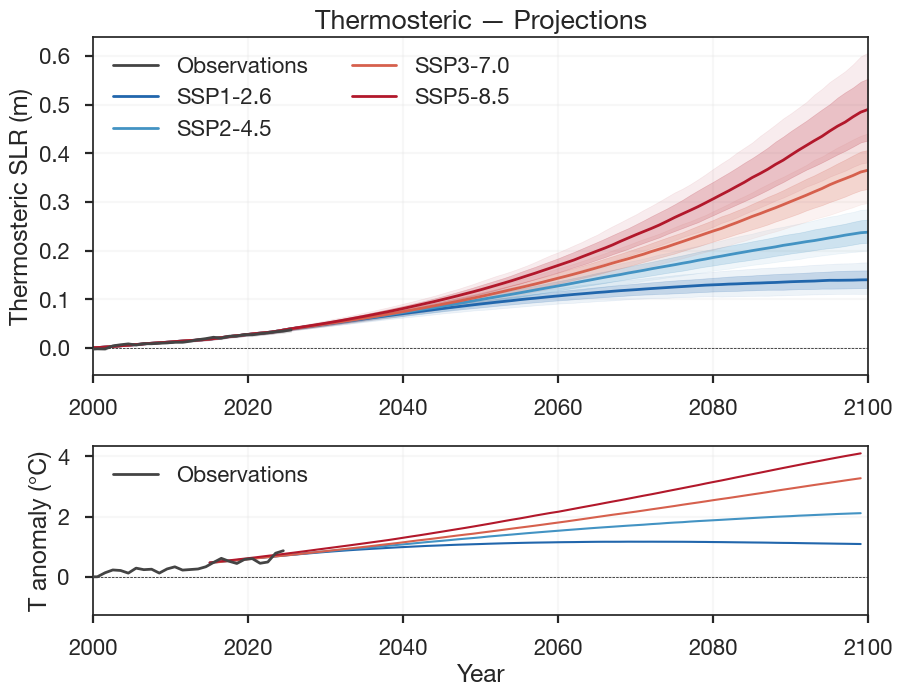

In [6]:
# ── Load saved projections from component_results.h5 ──
from component_io import load_all_projections, load_component, PROJ_YEARS, PROJ_SSPS
from component_projections import read_ipcc_component_nc, ipcc_extract

_, all_proj = load_all_projections()
thermo_proj = all_proj['ocean']  # keyed by SSP

# Load observations from HDF5 (full-depth corrected)
ocean_data = load_component('ocean')
ocean_obs = ocean_data['observations']

CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'
SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}

# ── Summary table ──
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
idx_2050 = np.argmin(np.abs(PROJ_YEARS - 2050))

print(f'{"SSP":>10} {"2050 med":>10} {"2100 med":>10} {"2100 [5-95]":>20}')
for ssp in PROJ_SSPS:
    med_50 = np.median(thermo_proj[ssp]['samples'][:, idx_2050]) * M_TO_MM
    med = np.median(thermo_proj[ssp]['samples'][:, idx_2100]) * M_TO_MM
    p5 = np.percentile(thermo_proj[ssp]['samples'][:, idx_2100], 5) * M_TO_MM
    p95 = np.percentile(thermo_proj[ssp]['samples'][:, idx_2100], 95) * M_TO_MM
    print(f'{ssp:>10} {med_50:>8.0f} mm {med:>8.0f} mm   [{p5:.0f}, {p95:.0f}]')

# ── Two-panel plot: projections + temperature ──
# Load SSP temperatures for lower panel, rebase to year 2000.
# SSP data starts at 2015, so get year-2000 temperature from Berkeley Earth
# and convert to SSP baseline using T_OFFSET (computed in projection cell).
SSP_H5_MAP = {'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
              'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5'}

# Berkeley Earth GMST at year 2000 (rel. 1951-1980), converted to SSP baseline
# SSP temps are rel. pre-industrial; Berkeley Earth is rel. 1951-1980
# T_SSP = T_Berkeley + T_OFFSET, so T_SSP_at_2000 = T_Berkeley_at_2000 + T_OFFSET
idx_be_2000 = np.argmin(np.abs(T_annual_years - BASELINE_YEAR))
T_at_2000_ssp_basis = T_annual[idx_be_2000] + T_OFFSET
print(f'GMST at year 2000 (SSP basis): {T_at_2000_ssp_basis:.3f} C')

temp_projections = {}
for ssp_name, h5_key in SSP_H5_MAP.items():
    temp_projections[ssp_name] = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')

temp_scenarios = {}
for ssp in PROJ_SSPS:
    df_t = temp_projections[ssp]
    t_years = df_t['decimal_year'].values
    t_vals = df_t['temperature'].values.copy()
    # Rebase to year 2000
    t_vals -= T_at_2000_ssp_basis
    temp_scenarios[ssp] = {
        'years': t_years,
        'temperature': t_vals,
    }

# Berkeley Earth observed GMST, rebased to year 2000
T_annual_rebased = T_annual - T_annual[idx_be_2000]

plot_component_projection_twopanel(
    comp_proj=thermo_proj,
    proj_years=PROJ_YEARS,
    component_name='Thermosteric',
    temperature_scenarios=temp_scenarios,
    temp_label='T anomaly (\u00b0C)',
    ssps=PROJ_SSPS,
    obs_years=ocean_obs['years'],
    obs_vals=ocean_obs['H_obs'],
    obs_sigma=ocean_obs['sigma'],
    obs_label='Observations',
    temp_obs_years=T_annual_years,
    temp_obs_vals=T_annual_rebased,
    temp_obs_label='Observations',
    save_path=f'{FIG_DIR}/component_ocean_twopanel.png',
    xlim=(2000, 2100),
)

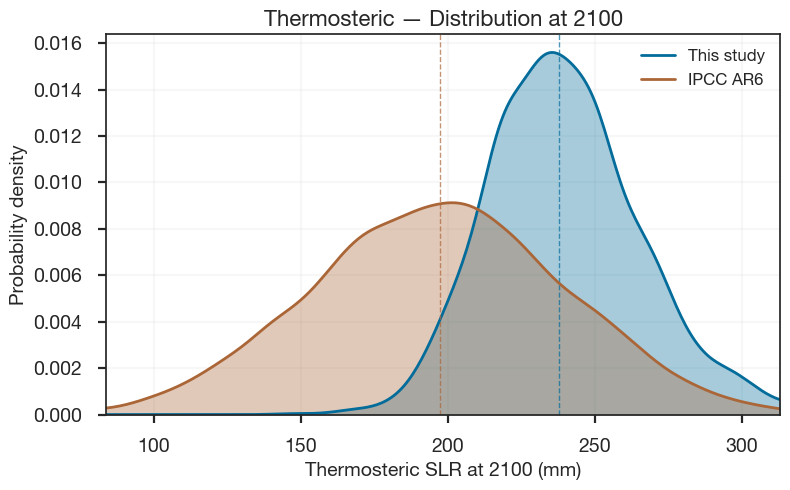

In [7]:
# ── Histogram: our distribution vs IPCC at 2100 ──
HIST_SSP = 'SSP2-4.5'
rng_hist = np.random.default_rng(99)

our_samples_2100 = thermo_proj[HIST_SSP]['samples'][:, idx_2100] * M_TO_MM

ipcc_data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence',
                                    SSP_CODE[HIST_SSP], 'oceandynamics')
sample_sets = [our_samples_2100]
labels = ['This study']
colors = ['C0']

if ipcc_data is not None:
    ipcc_ex = ipcc_extract(ipcc_data)
    yr_idx = np.argmin(np.abs(ipcc_ex['years'] - 2100))
    ipcc_med = ipcc_ex['q50'][yr_idx]
    ipcc_sig = (ipcc_ex['q95'][yr_idx] - ipcc_ex['q05'][yr_idx]) / (2 * Z_90)
    ipcc_samples_2100 = rng_hist.normal(ipcc_med, ipcc_sig, 10000)
    sample_sets.append(ipcc_samples_2100)
    labels.append('IPCC AR6')
    colors.append('C1')

plot_component_histogram(
    sample_sets=sample_sets,
    labels=labels,
    colors=colors,
    component_name='Thermosteric',
    year=2100,
    fontsize={'title': 16, 'legend': 12, 'xlabel': 14, 'xtick': 14, 'ylabel': 14, 'ytick': 14},
    save_path=f'{FIG_DIR}/component_ocean_histogram_2100.png',
)


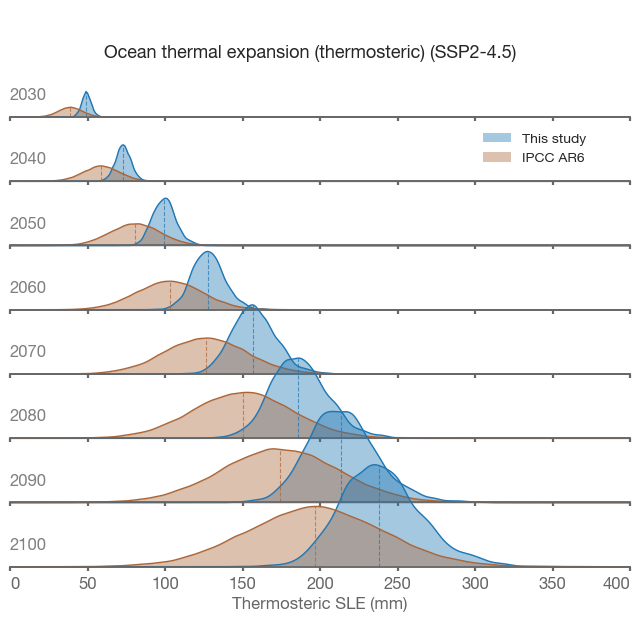

In [8]:
# ── Ridge plot ──
RIDGE_YEARS = list(range(2030, 2110, 10))
RIDGE_SSP = 'SSP2-4.5'
rng_ridge = np.random.default_rng(202)

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    our_s = thermo_proj[RIDGE_SSP]['samples'][:, idx_yr] * M_TO_MM
    year_dict = {'This study': our_s}

    if ipcc_data is not None:
        yr_idx_ipcc = np.argmin(np.abs(ipcc_ex['years'] - yr))
        if np.abs(ipcc_ex['years'][yr_idx_ipcc] - yr) < 5:
            ipcc_med_yr = ipcc_ex['q50'][yr_idx_ipcc]
            ipcc_sig_yr = (ipcc_ex['q95'][yr_idx_ipcc] - ipcc_ex['q05'][yr_idx_ipcc]) / (2 * Z_90)
            year_dict['IPCC AR6'] = rng_ridge.normal(ipcc_med_yr, ipcc_sig_yr, 50000)
    samples_by_year[yr] = year_dict

plot_component_ridge(
    samples_by_year=samples_by_year,
    source_colors={'This study': 'tab:blue', 'IPCC AR6': 'C1'},
    component_name='Thermosteric',
    ssp_label=RIDGE_SSP,
    xlabel='Thermosteric SLE (mm)',
    title=f'Ocean thermal expansion (thermosteric) ({RIDGE_SSP})',
    xlim=(0,400),
    top=1.04, legend_bbox=(0.95, -0.03),
    fontsize={'year': 12, 'title': 13, 'legend': 10, 'xlabel': 12, 'xtick': 12},
    save_path=f'{FIG_DIR}/component_ocean_ridge.png',
)
